In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import find_peaks
import itertools
import io

In [2]:
plt.rcParams['font.family'] = 'Arial'

In [3]:
spikingexp_control=pd.read_excel(r'C:\Users\yaras\OneDrive\Desktop\Analysis for paper\Python Code\spiking_exp.xlsx', sheet_name='control')
spikingexp_spiked=pd.read_excel(r'C:\Users\yaras\OneDrive\Desktop\Analysis for paper\Python Code\spiking_exp.xlsx', sheet_name='spiked')

In [4]:
spikingexp_control.head()

,Day,R1,R2,R3,R4,R5,R6,R7,R8,R9,...,R27,R28,R29,R30,R31,R32,R33,R34,R35,R36
0,Media,PRO99,PRO99,lowN (1:8),lowN (1:8),lowP (1:8),lowP (1:8),lowP (1:50),lowP (1:50),PRO99,...,lowP (1:50),lowP (1:50),PRO99,PRO99,lowN (1:8),lowN (1:8),lowP (1:8),lowP (1:8),lowP (1:50),lowP (1:50)
1,Strain,MIT9312,MIT9312,MIT9312,MIT9312,MIT9312,MIT9312,MIT9312,MIT9312,MED4,...,PAC1,PAC1,MIT1314,MIT1314,MIT1314,MIT1314,MIT1314,MIT1314,MIT1314,MIT1314
2,0,0.034,-0.005,0.143,0.117,0.163,0.183,0.083,0.083,0.039,...,0.137,0.209,0.049,0.02,0.124,0.137,0.082,0.059,0.102,0.104
3,0.926389,0.199,0.147,0.166,0.186,0.158,0.195,0.147,0.136,0.169,...,0.251,0.232,0.247,0.178,0.201,0.209,0.107,0.142,0.112,0.136
4,1.941667,0.276,0.247,0.197,0.256,0.255,0.257,0.206,0.166,0.231,...,0.329,0.299,0.25,0.225,0.241,0.254,0.208,0.178,0.13,0.155


In [5]:
spikingexp_spiked.head()

,Day,S1,S2,S3,S4,S5,S6,S7,S8,S9,...,S27,S28,S29,S30,S31,S32,S33,S34,S35,S36
0,Media,PRO99,PRO99,lowN (1:8),lowN (1:8),lowP (1:8),lowP (1:8),lowP (1:50),lowP (1:50),PRO99,...,lowP (1:50),lowP (1:50),PRO99,PRO99,lowN (1:8),lowN (1:8),lowP (1:8),lowP (1:8),lowP (1:50),lowP (1:50)
1,Strain,MIT9312,MIT9312,MIT9312,MIT9312,MIT9312,MIT9312,MIT9312,MIT9312,MED4,...,PAC1,PAC1,MIT1314,MIT1314,MIT1314,MIT1314,MIT1314,MIT1314,MIT1314,MIT1314
2,0,0.175,0.167,0.102,0.088,0.102,0.078,0.143,0.123,0.117,...,0.22,0.207,0.155,0.03,0.145,0.166,0.073,0.123,0.118,0.108
3,0.926389,0.185,0.122,0.142,0.157,0.127,0.153,0.165,0.175,0.137,...,0.254,0.217,0.165,0.127,0.203,0.182,0.163,0.107,0.114,0.099
4,1.941667,0.245,0.257,0.19,0.177,0.233,0.224,0.18,0.255,0.225,...,0.332,0.378,0.185,0.17,0.219,0.243,0.201,0.219,0.145,0.135


In [6]:
spikingexp_control=spikingexp_control.drop(spikingexp_control.index[:2])
spikingexp_spiked=spikingexp_spiked.drop(spikingexp_spiked.index[:2])

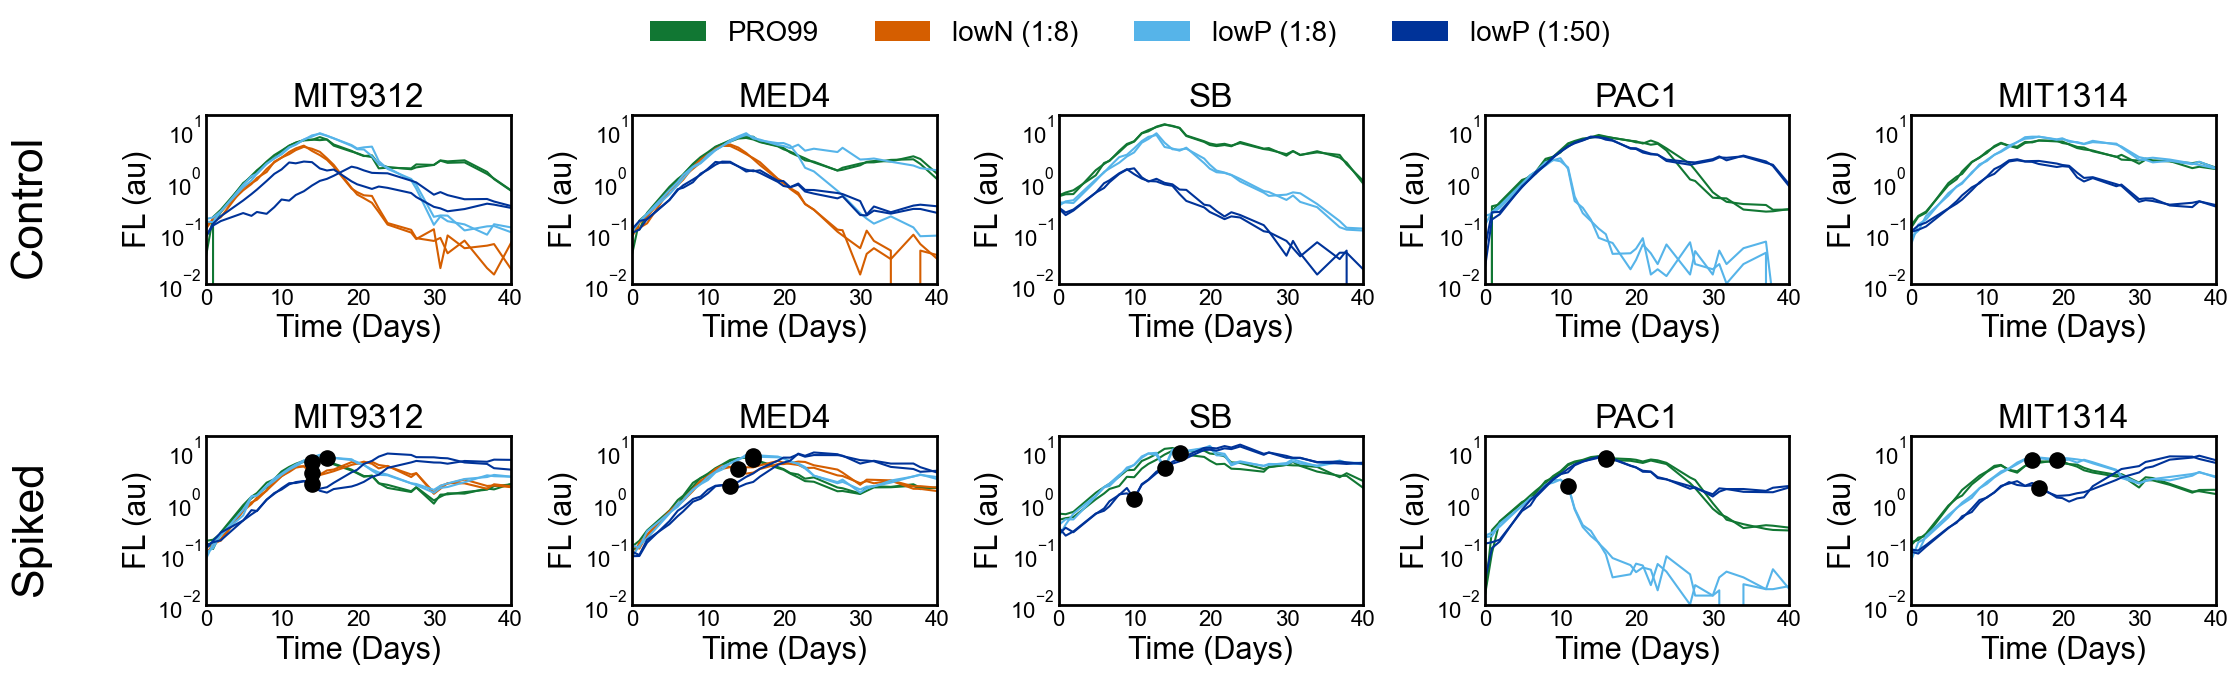

In [7]:
spiking_time = """Media	Strain	FL	Spikingdate
PRO99	MIT9312	6.072	13.92
PRO99	MIT9312	6.177	13.92
lowN (1:8)	MIT9312	3.701	13.92
lowN (1:8)	MIT9312	3.751	13.92
lowP (1:8)	MIT9312	6.91	15.89
lowP (1:8)	MIT9312	7.415	15.89
lowP (1:50)	MIT9312	2.153	13.92
lowP (1:50)	MIT9312	2.452	13.92
PRO99	MED4	7.142	15.89
PRO99	MED4	6.708	15.89
lowN (1:8)	MED4	4.459	13.92
lowN (1:8)	MED4	4.545	13.92
lowP (1:8)	MED4	7.784	15.89
lowP (1:8)	MED4	8.071	15.89
lowP (1:50)	MED4	1.978	12.85555556
lowP (1:50)	MED4	2.105	12.85555556
PRO99	SB	8.237	15.89
PRO99	SB	10.438	15.89
lowP (1:8)	SB	4.438	13.92
lowP (1:8)	SB	4.705	13.92
lowP (1:50)	SB	1.136	9.924305556
lowP (1:50)	SB	1.206	9.924305556
PRO99	PAC1	6.946	15.89
PRO99	PAC1	7.194	15.89
lowP (1:8)	PAC1	7.228	15.89
lowP (1:8)	PAC1	7.21	15.89
lowP (1:50)	PAC1	2.059	10.92361111
lowP (1:50)	PAC1	2.153	10.92361111
PRO99	MIT1314	6.595	15.89
PRO99	MIT1314	6.624	15.89
lowP (1:8)	MIT1314	6.661	19.12
lowP (1:8)	MIT1314	6.909	19.12
lowP (1:50)	MIT1314	1.825	16.78
lowP (1:50)	MIT1314	2.044	16.78
PRO99	MIT9515	6.675	16.78
PRO99	MIT9515	6.651	16.78
lowP (1:8)	MIT9515	4.761	19.12
lowP (1:8)	MIT9515	4.028	19.12
lowP (1:50)	MIT9515	0.468	14.95694444
lowP (1:50)	MIT9515	0.477	14.95694444"""

metadata = pd.read_csv(io.StringIO(spiking_time), sep="\t")


def mark_spiking_point(strain, media):
    """Helper function to find metadata points and plot a large black dot."""
    sub_df = metadata[
        (metadata["Strain"] == strain) & (metadata["Media"] == media)
    ]
    if not sub_df.empty:
        x_val = sub_df["Spikingdate"].mean()
        y_val = sub_df["FL"].mean()
        plt.scatter(x_val, y_val, color="black", marker="o", s=120, zorder=5)


def format_axis_and_ticks(ax):
    """Helper function to apply consistent axis spine and remove tick marks."""
    for spine in ["top", "bottom", "left", "right"]:
        ax.spines[spine].set_linewidth(2)

    ax.tick_params(
        axis="both",
        which="major",
        colors="black",
        labelsize=16,
        width=2,
        length=0,
    )
    ax.tick_params(axis="both", which="minor", width=1.5, length=0)


fig = plt.figure(figsize=(28, 7))

plt.subplots_adjust(
    left=0.09, bottom=0.15, right=0.96, top=0.85, wspace=0.4, hspace=0.9
)

fig.text(
    0.02,
    0.72,
    "Control",
    fontsize=32,
    fontweight="normal",
    color="black",
    rotation="vertical",
    va="center",
)
fig.text(
    0.02,
    0.26,
    "Spiked",
    fontsize=32,
    fontweight="normal",
    color="black",
    rotation="vertical",
    va="center",
)


# Subplot 1
ax = plt.subplot(2, 6, 1)
plt.yscale("log")
plt.xlim(0, 40)
plt.ylim(10**-2, 10**1.3)
plt.plot(
    spikingexp_control["Day"],
    spikingexp_control["R1"],
    color="#117733",
    label="PRO99",
)
plt.plot(spikingexp_control["Day"], spikingexp_control["R2"], color="#117733")
plt.plot(
    spikingexp_control["Day"],
    spikingexp_control["R3"],
    color="#D55E00",
    label="lowN (1:8)",
)
plt.plot(spikingexp_control["Day"], spikingexp_control["R4"], color="#D55E00")
plt.plot(
    spikingexp_control["Day"],
    spikingexp_control["R5"],
    color="#56B4E9",
    label="lowP (1:8)",
)
plt.plot(spikingexp_control["Day"], spikingexp_control["R6"], color="#56B4E9")
plt.plot(
    spikingexp_control["Day"],
    spikingexp_control["R7"],
    color="#003399",
    label="lowP (1:50)",
)
plt.plot(spikingexp_control["Day"], spikingexp_control["R8"], color="#003399")
plt.title("MIT9312", fontsize=24, color="black", fontweight="normal")
plt.ylabel("FL (au)", fontsize=22)
plt.xlabel("Time (Days)", fontsize=22)
format_axis_and_ticks(ax)

# Subplot 2
ax = plt.subplot(2, 6, 2)
plt.yscale("log")
plt.xlim(0, 40)
plt.ylim(10**-2, 10**1.3)
plt.plot(
    spikingexp_control["Day"],
    spikingexp_control["R9"],
    color="#117733",
    label="PRO99",
)
plt.plot(
    spikingexp_control["Day"], spikingexp_control["R10"], color="#117733"
)
plt.plot(
    spikingexp_control["Day"],
    spikingexp_control["R11"],
    color="#D55E00",
    label="lowN (1:8)",
)
plt.plot(
    spikingexp_control["Day"], spikingexp_control["R12"], color="#D55E00"
)
plt.plot(
    spikingexp_control["Day"],
    spikingexp_control["R13"],
    color="#56B4E9",
    label="lowP (1:8)",
)
plt.plot(
    spikingexp_control["Day"], spikingexp_control["R14"], color="#56B4E9"
)
plt.plot(
    spikingexp_control["Day"],
    spikingexp_control["R15"],
    color="#003399",
    label="lowP (1:50)",
)
plt.plot(
    spikingexp_control["Day"], spikingexp_control["R16"], color="#003399"
)
plt.title("MED4", fontsize=24, color="black", fontweight="normal")
plt.ylabel("FL (au)", fontsize=22)
plt.xlabel("Time (Days)", fontsize=22)
format_axis_and_ticks(ax)

# Subplot 3
ax = plt.subplot(2, 6, 3)
plt.yscale("log")
plt.xlim(0, 40)
plt.ylim(10**-2, 10**1.3)
plt.plot(
    spikingexp_control["Day"],
    spikingexp_control["R17"],
    color="#117733",
    label="PRO9",
)
plt.plot(
    spikingexp_control["Day"], spikingexp_control["R18"], color="#117733"
)
plt.plot(
    spikingexp_control["Day"],
    spikingexp_control["R19"],
    color="#56B4E9",
    label="lowP (1:8)",
)
plt.plot(
    spikingexp_control["Day"], spikingexp_control["R20"], color="#56B4E9"
)
plt.plot(
    spikingexp_control["Day"],
    spikingexp_control["R21"],
    color="#003399",
    label="lowP (1:50)",
)
plt.plot(
    spikingexp_control["Day"], spikingexp_control["R22"], color="#003399"
)
plt.title("SB", fontsize=24, color="black", fontweight="normal")
plt.ylabel("FL (au)", fontsize=22)
plt.xlabel("Time (Days)", fontsize=22)
format_axis_and_ticks(ax)

# Subplot 4
ax = plt.subplot(2, 6, 4)
plt.yscale("log")
plt.xlim(0, 40)
plt.ylim(10**-2, 10**1.3)
plt.plot(
    spikingexp_control["Day"],
    spikingexp_control["R23"],
    color="#117733",
    label="Pro99",
)
plt.plot(
    spikingexp_control["Day"], spikingexp_control["R24"], color="#117733"
)
plt.plot(
    spikingexp_control["Day"],
    spikingexp_control["R27"],
    color="#56B4E9",
    label="lowP (1:8)",
)
plt.plot(
    spikingexp_control["Day"], spikingexp_control["R28"], color="#56B4E9"
)
plt.plot(
    spikingexp_control["Day"],
    spikingexp_control["R29"],
    color="#003399",
    label="lowP (1:50)",
)
plt.plot(
    spikingexp_control["Day"], spikingexp_control["R30"], color="#003399"
)
plt.title("PAC1", fontsize=24, color="black", fontweight="normal")
plt.ylabel("FL (au)", fontsize=22)
plt.xlabel("Time (Days)", fontsize=22)
format_axis_and_ticks(ax)

# Subplot 5
ax = plt.subplot(2, 6, 5)
plt.yscale("log")
plt.xlim(0, 40)
plt.ylim(10**-2, 10**1.3)
plt.plot(
    spikingexp_control["Day"],
    spikingexp_control["R31"],
    color="#117733",
    label="Pro99",
)
plt.plot(
    spikingexp_control["Day"], spikingexp_control["R32"], color="#117733"
)
plt.plot(
    spikingexp_control["Day"],
    spikingexp_control["R33"],
    color="#56B4E9",
    label="lowP (1:8)",
)
plt.plot(
    spikingexp_control["Day"], spikingexp_control["R34"], color="#56B4E9"
)
plt.plot(
    spikingexp_control["Day"],
    spikingexp_control["R35"],
    color="#003399",
    label="lowP (1:50)",
)
plt.plot(
    spikingexp_control["Day"], spikingexp_control["R36"], color="#003399"
)
plt.title("MIT1314", fontsize=24, color="black", fontweight="normal")
plt.ylabel("FL (au)", fontsize=22)
plt.xlabel("Time (Days)", fontsize=22)
format_axis_and_ticks(ax)


# Subplot 7
ax = plt.subplot(2, 6, 7)
plt.yscale("log")
plt.xlim(0, 40)
plt.ylim(10**-2, 10**1.3)
plt.plot(
    spikingexp_spiked["Day"],
    spikingexp_spiked["S1"],
    color="#117733",
    label="Pro99",
)
plt.plot(spikingexp_spiked["Day"], spikingexp_spiked["S2"], color="#117733")
plt.plot(
    spikingexp_spiked["Day"],
    spikingexp_spiked["S3"],
    color="#D55E00",
    label="lowN (1:8)",
)
plt.plot(spikingexp_spiked["Day"], spikingexp_spiked["S4"], color="#D55E00")
plt.plot(
    spikingexp_spiked["Day"],
    spikingexp_spiked["S5"],
    color="#56B4E9",
    label="lowP (1:8)",
)
plt.plot(spikingexp_spiked["Day"], spikingexp_spiked["S6"], color="#56B4E9")
plt.plot(
    spikingexp_spiked["Day"],
    spikingexp_spiked["S7"],
    color="#003399",
    label="lowP (1:50)",
)
plt.plot(spikingexp_spiked["Day"], spikingexp_spiked["S8"], color="#003399")
plt.title("MIT9312", fontsize=24, color="black", fontweight="normal")
plt.ylabel("FL (au)", fontsize=22)
plt.xlabel("Time (Days)", fontsize=22)
format_axis_and_ticks(ax)
mark_spiking_point("MIT9312", "PRO99")
mark_spiking_point("MIT9312", "lowN (1:8)")
mark_spiking_point("MIT9312", "lowP (1:8)")
mark_spiking_point("MIT9312", "lowP (1:50)")

# Subplot 8
ax = plt.subplot(2, 6, 8)
plt.yscale("log")
plt.xlim(0, 40)
plt.ylim(10**-2, 10**1.3)
plt.plot(
    spikingexp_spiked["Day"],
    spikingexp_spiked["S9"],
    color="#117733",
    label="Pro99",
)
plt.plot(spikingexp_spiked["Day"], spikingexp_spiked["S10"], color="#117733")
plt.plot(
    spikingexp_spiked["Day"],
    spikingexp_spiked["S11"],
    color="#D55E00",
    label="lowN (1:8)",
)
plt.plot(spikingexp_spiked["Day"], spikingexp_spiked["S12"], color="#D55E00")
plt.plot(
    spikingexp_spiked["Day"],
    spikingexp_spiked["S13"],
    color="#56B4E9",
    label="lowP (1:8)",
)
plt.plot(spikingexp_spiked["Day"], spikingexp_spiked["S14"], color="#56B4E9")
plt.plot(
    spikingexp_spiked["Day"],
    spikingexp_spiked["S15"],
    color="#003399",
    label="lowP (1:50)",
)
plt.plot(spikingexp_spiked["Day"], spikingexp_spiked["S16"], color="#003399")
plt.title("MED4", fontsize=24, color="black", fontweight="normal")
plt.ylabel("FL (au)", fontsize=22)
plt.xlabel("Time (Days)", fontsize=22)
format_axis_and_ticks(ax)
mark_spiking_point("MED4", "PRO99")
mark_spiking_point("MED4", "lowN (1:8)")
mark_spiking_point("MED4", "lowP (1:8)")
mark_spiking_point("MED4", "lowP (1:50)")

# Subplot 9
ax = plt.subplot(2, 6, 9)
plt.yscale("log")
plt.xlim(0, 40)
plt.ylim(10**-2, 10**1.3)
plt.plot(
    spikingexp_spiked["Day"],
    spikingexp_spiked["S17"],
    color="#117733",
    label="Pro99",
)
plt.plot(spikingexp_spiked["Day"], spikingexp_spiked["S18"], color="#117733")
plt.plot(
    spikingexp_spiked["Day"],
    spikingexp_spiked["S19"],
    color="#56B4E9",
    label="lowP (1:8)",
)
plt.plot(spikingexp_spiked["Day"], spikingexp_spiked["S20"], color="#56B4E9")
plt.plot(
    spikingexp_spiked["Day"],
    spikingexp_spiked["S21"],
    color="#003399",
    label="lowP (1:50)",
)
plt.plot(spikingexp_spiked["Day"], spikingexp_spiked["S22"], color="#003399")
plt.title("SB", fontsize=24, color="black", fontweight="normal")
plt.ylabel("FL (au)", fontsize=22)
plt.xlabel("Time (Days)", fontsize=22)
format_axis_and_ticks(ax)
mark_spiking_point("SB", "PRO99")
mark_spiking_point("SB", "lowP (1:8)")
mark_spiking_point("SB", "lowP (1:50)")

# Subplot 10
ax = plt.subplot(2, 6, 10)
plt.yscale("log")
plt.xlim(0, 40)
plt.ylim(10**-2, 10**1.3)
plt.plot(
    spikingexp_spiked["Day"],
    spikingexp_spiked["S23"],
    color="#117733",
    label="Pro99",
)
plt.plot(spikingexp_spiked["Day"], spikingexp_spiked["S24"], color="#117733")
plt.plot(
    spikingexp_spiked["Day"],
    spikingexp_spiked["S27"],
    color="#56B4E9",
    label="lowP (1:8)",
)
plt.plot(spikingexp_spiked["Day"], spikingexp_spiked["S28"], color="#56B4E9")
plt.plot(
    spikingexp_spiked["Day"],
    spikingexp_spiked["S29"],
    color="#003399",
    label="lowP (1:50)",
)
plt.plot(spikingexp_spiked["Day"], spikingexp_spiked["S30"], color="#003399")
plt.title("PAC1", fontsize=24, color="black", fontweight="normal")
plt.ylabel("FL (au)", fontsize=22)
plt.xlabel("Time (Days)", fontsize=22)
format_axis_and_ticks(ax)
mark_spiking_point("PAC1", "PRO99")
mark_spiking_point("PAC1", "lowP (1:8)")
mark_spiking_point("PAC1", "lowP (1:50)")

# Subplot 11
ax = plt.subplot(2, 6, 11)
plt.yscale("log")
plt.xlim(0, 40)
plt.ylim(10**-2, 10**1.3)
plt.plot(
    spikingexp_spiked["Day"],
    spikingexp_spiked["S31"],
    color="#117733",
    label="PRO99",
)
plt.plot(spikingexp_spiked["Day"], spikingexp_spiked["S32"], color="#117733")
plt.plot(
    spikingexp_spiked["Day"],
    spikingexp_spiked["S33"],
    color="#56B4E9",
    label="lowP (1:8)",
)
plt.plot(spikingexp_spiked["Day"], spikingexp_spiked["S34"], color="#56B4E9")
plt.plot(
    spikingexp_spiked["Day"],
    spikingexp_spiked["S35"],
    color="#003399",
    label="lowP (1:50)",
)
plt.plot(spikingexp_spiked["Day"], spikingexp_spiked["S36"], color="#003399")
plt.title("MIT1314", fontsize=24, color="black", fontweight="normal")
plt.ylabel("FL (au)", fontsize=22)
plt.xlabel("Time (Days)", fontsize=22)
format_axis_and_ticks(ax)
mark_spiking_point("MIT1314", "PRO99")
mark_spiking_point("MIT1314", "lowP (1:8)")
mark_spiking_point("MIT1314", "lowP (1:50)")


custom_handles = [
    mpatches.Rectangle((0, 0), 1, 1, facecolor="#117733", label="PRO99"),
    mpatches.Rectangle((0, 0), 1, 1, facecolor="#D55E00", label="lowN (1:8)"),
    mpatches.Rectangle((0, 0), 1, 1, facecolor="#56B4E9", label="lowP (1:8)"),
    mpatches.Rectangle((0, 0), 1, 1, facecolor="#003399", label="lowP (1:50)"),
]

fig.legend(
    handles=custom_handles,
    loc="upper center",
    bbox_to_anchor=(0.42, 1.02),
    ncol=4,
    fontsize=20,
    frameon=False,
)

plt.savefig("spiking_exp", dpi=128, bbox_inches="tight")
plt.show()

In [8]:
def peaks(m, i, h, t, d, growth_curves):
    peaks_list = []
    max_values_list = []

    for j in range(1, int(m)):
        z = f"{i}{j}"
        if z not in growth_curves.columns:
            continue

        y = growth_curves[z]
        x = growth_curves["Day"]

        # 1. Extract Peaks
        peaks_idx, _ = find_peaks(y, height=h, threshold=t, distance=d)
        peaks_pos = x.iloc[peaks_idx].values
        peaks_height = y.iloc[peaks_idx].values

        peaks_df = pd.DataFrame(
            {
                "number_of_tube": z,
                "position": peaks_pos,
                "height": peaks_height,
                "height_parameter": h,
                "threshold_parameter": t,
                "distance_parameter": d,
            }
        )
        peaks_list.append(peaks_df)

        # 2. Extract Max Values
        max_idx = y.idxmax()
        max_in_curve = y.loc[max_idx]
        max_position = x.loc[max_idx]

        max_df = pd.DataFrame(
            {
                "number_of_tube": z,
                "height": max_in_curve,
                "position": max_position,
                "height_parameter": h,
                "threshold_parameter": t,
                "distance_parameter": d,
            },
            index=[0],
        )
        max_values_list.append(max_df)

    all_peaks = (
        pd.concat(peaks_list, ignore_index=True)
        if peaks_list
        else pd.DataFrame()
    )
    max_values_df = (
        pd.concat(max_values_list, ignore_index=True)
        if max_values_list
        else pd.DataFrame()
    )

    if not all_peaks.empty:
        all_peaks["tube_num"] = (
            all_peaks["number_of_tube"].str.extract(r"(\d+)")[0].astype(int)
        )
        all_peaks = all_peaks.sort_values(by=["tube_num", "number_of_tube"])
        all_peaks = all_peaks.drop(columns=["tube_num"]).reset_index(drop=True)
        all_peaks = all_peaks.drop_duplicates()

    return all_peaks, max_values_df


def count(all_peaks, column_name, m, i):
    count_list = []
    for j in range(1, int(m)):
        z = f"{i}{j}"
        count_val = (
            all_peaks[column_name].value_counts().get(z, 0)
            if not all_peaks.empty
            else 0
        )
        count_df = pd.DataFrame(
            {"number_of_tube": z, "peak_count": count_val}, index=[0]
        )
        count_list.append(count_df)

    return pd.concat(count_list, ignore_index=True)


def d_value(m, i, max_values, growth_curves):
    max_values["max_min_diff"] = max_values["height"].sub(0.15)
    max_values["y_90decline"] = max_values["max_min_diff"].multiply(0.10)

    position_of_90decline_lst = []

    for j in range(1, int(m)):
        z = f"{i}{j}"
        if z not in growth_curves.columns:
            continue

        growth_of_z = growth_curves[["Day", z]]
        max_of_z = max_values.loc[max_values["number_of_tube"] == z]
        if max_of_z.empty:
            continue
        max_of_z = max_of_z.squeeze()

        decline_condition = (growth_of_z.Day > max_of_z.position) & (
            growth_of_z[z] <= max_of_z.y_90decline
        )
        position = (
            growth_of_z.loc[decline_condition]["Day"].min()
            if decline_condition.any()
            else np.nan
        )

        decline_position_df = pd.DataFrame(
            {"number_of_tube": z, "position_of_90decline": position}, index=[0]
        )
        position_of_90decline_lst.append(decline_position_df)

    if position_of_90decline_lst:
        position_of_90decline = pd.concat(
            position_of_90decline_lst, ignore_index=True
        )
        max_values = max_values.merge(
            position_of_90decline, on="number_of_tube", how="left"
        )
        max_values["D_value"] = (
            max_values["position_of_90decline"] - max_values["position"]
        )
    else:
        position_of_90decline = pd.DataFrame(
            columns=["number_of_tube", "position_of_90decline"]
        )
        max_values["position_of_90decline"] = np.nan
        max_values["D_value"] = np.nan

    return position_of_90decline, max_values


def add_experimental_metadata(count_df, max_df, prefix):
    layout = {}

    def add_tubes(start, strain, conditions):
        current_tube = start
        for cond in conditions:
            layout[f"{prefix}{current_tube}"] = {"strain": strain, "media": cond}
            layout[f"{prefix}{current_tube+1}"] = {
                "strain": strain,
                "media": cond,
            }
            current_tube += 2
        return current_tube

    all_4_media = ["Pro99", "lowN (1:8)", "lowP (1:8)", "lowP (1:50)"]
    missing_lowN_media = ["Pro99", "lowP (1:8)", "lowP (1:50)"]

    next_tube = add_tubes(1, "MIT9312", all_4_media)
    next_tube = add_tubes(next_tube, "MED4", all_4_media)
    next_tube = add_tubes(next_tube, "SB", missing_lowN_media)
    next_tube = add_tubes(next_tube, "PAC1", missing_lowN_media)
    next_tube = add_tubes(next_tube, "MIT1314", all_4_media)

    output_dfs = []
    for df in [count_df, max_df]:
        if not df.empty:
            df["strain"] = df["number_of_tube"].map(
                lambda x: layout.get(x, {}).get("strain", "Unknown")
            )
            df["media"] = df["number_of_tube"].map(
                lambda x: layout.get(x, {}).get("media", "Unknown")
            )

            cols = ["number_of_tube", "media", "strain"] + [
                c
                for c in df.columns
                if c not in ["number_of_tube", "media", "strain"]
            ]
            df = df[cols]
        output_dfs.append(df)

    return output_dfs[0], output_dfs[1]

In [9]:
m = 37
h = 0.15
t = 0.05
d = None
column_name = "number_of_tube"


# PROCESS CONTROL (R)
growth_curves_control = spikingexp_control
i_ctrl = "R"

all_peaks_ctrl, max_values_ctrl = peaks(
    m, i_ctrl, h, t, d, growth_curves_control
)
count_peaks_ctrl = count(all_peaks_ctrl, column_name, m, i_ctrl)
_, max_values_ctrl = d_value(m, i_ctrl, max_values_ctrl, growth_curves_control)

count_peaks_ctrl, max_values_ctrl = add_experimental_metadata(
    count_peaks_ctrl, max_values_ctrl, prefix=i_ctrl
)

pro99_means_ctrl = (
    max_values_ctrl[max_values_ctrl["media"] == "Pro99"]
    .groupby("strain")["height"]
    .mean()
)
strain_baselines_ctrl = max_values_ctrl["strain"].map(pro99_means_ctrl)
max_values_ctrl["norm_topro99"] = (
    max_values_ctrl["height"] / strain_baselines_ctrl
) * 100

control_parameters = pd.merge(
    max_values_ctrl,
    count_peaks_ctrl,
    on=["number_of_tube", "media", "strain"],
    how="left",
)



In [10]:
# PROCESS SPIKED (S) 
growth_curves_spiked = spikingexp_spiked
i_spike = "S"

all_peaks_spike, max_values_spike = peaks(
    m, i_spike, h, t, d, growth_curves_spiked
)
count_peaks_spike = count(all_peaks_spike, column_name, m, i_spike)
_, max_values_spike = d_value(m, i_spike, max_values_spike, growth_curves_spiked)

count_peaks_spike, max_values_spike = add_experimental_metadata(
    count_peaks_spike, max_values_spike, prefix=i_spike
)

pro99_means_spike = (
    max_values_spike[max_values_spike["media"] == "Pro99"]
    .groupby("strain")["height"]
    .mean()
)
strain_baselines_spike = max_values_spike["strain"].map(pro99_means_spike)
max_values_spike["norm_topro99"] = (
    max_values_spike["height"] / strain_baselines_spike
) * 100

spiked_parameters = pd.merge(
    max_values_spike,
    count_peaks_spike,
    on=["number_of_tube", "media", "strain"],
    how="left",
)

In [11]:
control_parameters["condition"] = "Control"
spiked_parameters["condition"] = "Spiked"

combined_df = pd.concat(
    [spiked_parameters, control_parameters], ignore_index=True
)



In [12]:
combined_df = combined_df[
    ~(
        (combined_df["strain"] == "MIT1314")
        & (combined_df["media"] == "lowN (1:8)")
    )
]

strain_order = ["MIT9312", "MED4", "SB", "PAC1", "MIT1314"]
media_types = ["PRO99", "lowN (1:8)", "lowP (1:8)", "lowP (1:50)"]

media_palette = {
    "PRO99": "#107833",
    "lowN (1:8)": "#cc5500",
    "lowP (1:8)": "#5dade2",
    "lowP (1:50)": "#002884",
}

condition_markers = {"Control": "o", "Spiked": "s"}

combined_df["media"] = combined_df["media"].replace("Pro99", "PRO99")
combined_df["media"] = pd.Categorical(
    combined_df["media"], categories=media_types, ordered=True
)

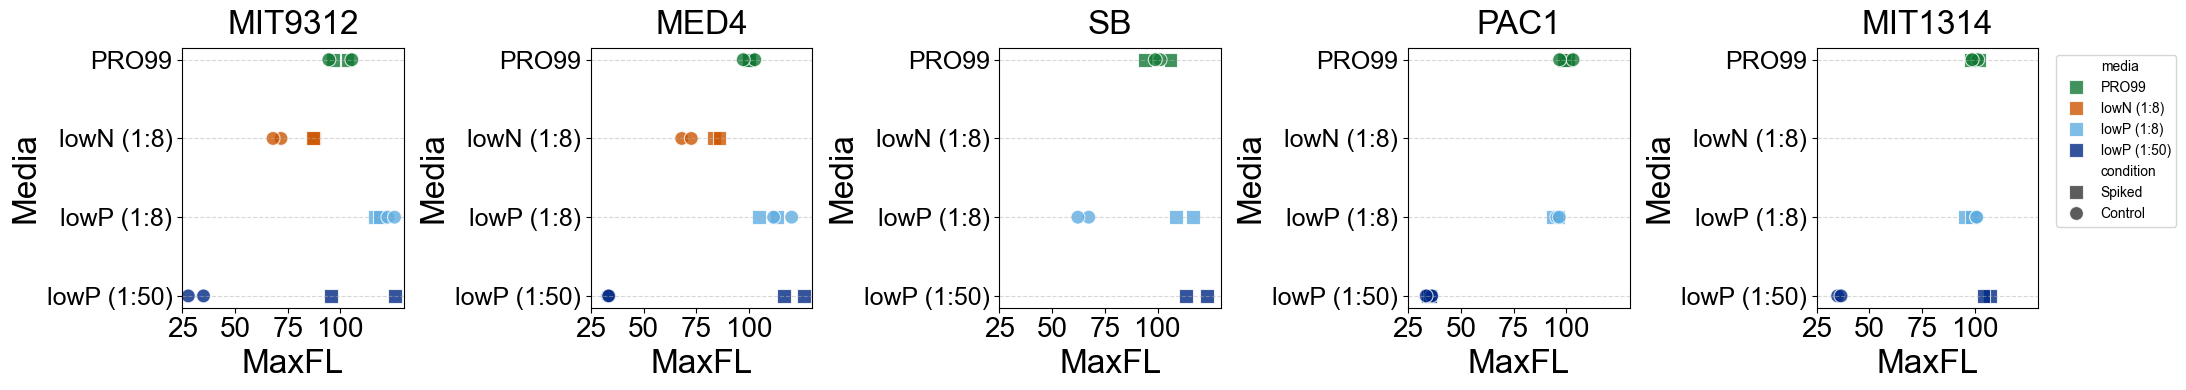

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for idx, strain in enumerate(strain_order):
    strain_data = combined_df[combined_df["strain"] == strain]
    ax = axes[idx]
    show_legend = True if idx == 4 else False

    sns.scatterplot(
        data=strain_data,
        x="norm_topro99",
        y="media",
        hue="media",
        style="condition",
        palette=media_palette,
        markers=condition_markers,
        alpha=0.8,
        s=100,
        ax=ax,
        legend=show_legend,
    )

    ax.set_title(strain, fontsize=24, pad=10)
    ax.set_xlabel("MaxFL", fontsize=24)
    

    ax.set_ylabel("Media", fontsize=24)
        
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    ax.set_xlim(25, 130)
    ax.set_xticks(np.arange(25, 121, 25))
    ax.tick_params(axis="x", labelsize=20)
    
    ax.tick_params(axis="y", labelsize=18)
    for label in ax.get_yticklabels():
        label.set_color("black")

sns.move_legend(axes[4], loc="upper left", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [14]:
combined_df

,number_of_tube,media,strain,height,position,height_parameter,threshold_parameter,distance_parameter,max_min_diff,y_90decline,position_of_90decline,D_value,norm_topro99,peak_count,condition
0,S1,PRO99,MIT9312,6.847,15.886806,0.15,0.05,None,6.697,0.6697,56.897917,41.011111,96.606702,5,Spiked
1,S2,PRO99,MIT9312,7.328,15.886806,0.15,0.05,None,7.178,0.7178,56.897917,41.011111,103.393298,5,Spiked
2,S3,lowN (1:8),MIT9312,6.190,20.744444,0.15,0.05,None,6.040,0.6040,56.897917,36.153472,87.336861,5,Spiked
3,S4,lowN (1:8),MIT9312,6.164,21.797917,0.15,0.05,None,6.014,0.6014,56.897917,35.100000,86.970018,4,Spiked
4,S5,lowP (1:8),MIT9312,8.255,14.956944,0.15,0.05,None,8.105,0.8105,47.864583,32.907639,116.472663,3,Spiked
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,R30,PRO99,MIT1314,7.236,14.956944,0.15,0.05,None,7.086,0.7086,40.700000,25.743056,98.697402,4,Control
68,R33,lowP (1:8),MIT1314,7.400,16.775000,0.15,0.05,None,7.250,0.7250,51.775000,35.000000,100.934324,4,Control
69,R34,lowP (1:8),MIT1314,7.389,15.886806,0.15,0.05,None,7.239,0.7239,51.775000,35.888194,100.784287,4,Control
70,R35,lowP (1:50),MIT1314,2.559,13.923611,0.15,0.05,None,2.409,0.2409,47.864583,33.940972,34.904181,6,Control


In [21]:
filtered_spiked = combined_df[combined_df['condition'] == 'Control']

In [22]:
filtered_spiked.head()

,number_of_tube,media,strain,height,position,height_parameter,threshold_parameter,distance_parameter,max_min_diff,y_90decline,position_of_90decline,D_value,norm_topro99,peak_count,condition
36,R1,PRO99,MIT9312,7.246,14.956944,0.15,0.05,None,7.096,0.7096,40.700000,25.743056,105.442375,3,Control
37,R2,PRO99,MIT9312,6.498,15.886806,0.15,0.05,None,6.348,0.6348,40.700000,24.813194,94.557625,6,Control
38,R3,lowN (1:8),MIT9312,4.938,12.855556,0.15,0.05,None,4.788,0.4788,22.693750,9.838194,71.856810,1,Control
39,R4,lowN (1:8),MIT9312,4.679,12.855556,0.15,0.05,None,4.529,0.4529,21.797917,8.942361,68.087893,1,Control
40,R5,lowP (1:8),MIT9312,8.417,14.956944,0.15,0.05,None,8.267,0.8267,29.932639,14.975694,122.482538,2,Control


In [20]:
intial_exp=pd.read_excel(r'C:\Users\yaras\OneDrive\Desktop\Analysis for paper\Python Code\traits_allgroups.xlsx')
intial_exp

,replicate,number_of_tube,media,strain,clade,ecotype,depth,location,max_FL,max_day,growth_rate,peak_count,D_value,norm_toPRO99
0,1,A1,PRO99,MED4,HLI,HL,5,Mediterranean,6.705,12.912500,0.377,3,20.147917,103.403074
1,2,A2,PRO99,MED4,HLI,HL,5,Mediterranean,6.457,14.018056,0.394,4,15.986111,99.578471
2,3,A3,PRO99,MED4,HLI,HL,5,Mediterranean,6.291,12.330556,0.391,4,16.456944,97.018455
3,1,A4,lowN (1:8),MED4,HLI,HL,5,Mediterranean,4.866,18.927778,0.395,1,9.859722,75.042410
4,2,A5,lowN (1:8),MED4,HLI,HL,5,Mediterranean,4.609,16.813194,0.393,1,9.290972,71.079011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,2,D56,lowP (1:8),NATL1A,LLI,LL,30,North_Atlantic,8.143,6.988194,0.433,2,9.915972,98.432589
248,3,D57,lowP (1:8),NATL1A,LLI,LL,30,North_Atlantic,7.740,6.988194,0.454,2,10.984722,93.561125
249,1,D58,lowP (1:50),NATL1A,LLI,LL,30,North_Atlantic,1.250,6.988194,0.223,3,12.330556,15.110001
250,2,D59,lowP (1:50),NATL1A,LLI,LL,30,North_Atlantic,1.128,6.988194,0.209,1,12.330556,13.635265


In [26]:
intial_exp = intial_exp[intial_exp['strain'].isin(['MIT9312', 'MED4', 'SB', 'PAC1', 'MIT1314'])]
intial_exp

,replicate,number_of_tube,media,strain,clade,ecotype,depth,location,max_FL,max_day,growth_rate,peak_count,D_value,norm_toPRO99
0,1,A1,PRO99,MED4,HLI,HL,5,Mediterranean,6.705,12.912500,0.377,3,20.147917,103.403074
1,2,A2,PRO99,MED4,HLI,HL,5,Mediterranean,6.457,14.018056,0.394,4,15.986111,99.578471
2,3,A3,PRO99,MED4,HLI,HL,5,Mediterranean,6.291,12.330556,0.391,4,16.456944,97.018455
3,1,A4,lowN (1:8),MED4,HLI,HL,5,Mediterranean,4.866,18.927778,0.395,1,9.859722,75.042410
4,2,A5,lowN (1:8),MED4,HLI,HL,5,Mediterranean,4.609,16.813194,0.393,1,9.290972,71.079011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,2,D44,lowP (1:8),MIT1314,HLII,HL,150,Station_ALOHA,5.762,6.988194,0.483,1,10.984722,84.764380
236,3,D45,lowP (1:8),MIT1314,HLII,HL,150,Station_ALOHA,5.671,6.988194,0.477,1,10.984722,83.425685
237,1,D46,lowP (1:50),MIT1314,HLII,HL,150,Station_ALOHA,1.555,6.988194,0.303,1,12.330556,22.875496
238,2,D47,lowP (1:50),MIT1314,HLII,HL,150,Station_ALOHA,1.452,6.988194,0.298,2,12.330556,21.360271


In [32]:
filtered_spiked = filtered_spiked.rename(columns={
    'norm_topro99': 'norm_toPRO99',
})

In [33]:
filtered_spiked.columns

Index(['number_of_tube', 'media', 'strain', 'height', 'position',
       'height_parameter', 'threshold_parameter', 'distance_parameter',
       'max_min_diff', 'y_90decline', 'position_of_90decline', 'D_value',
       'norm_toPRO99', 'peak_count', 'condition'],
      dtype='object')

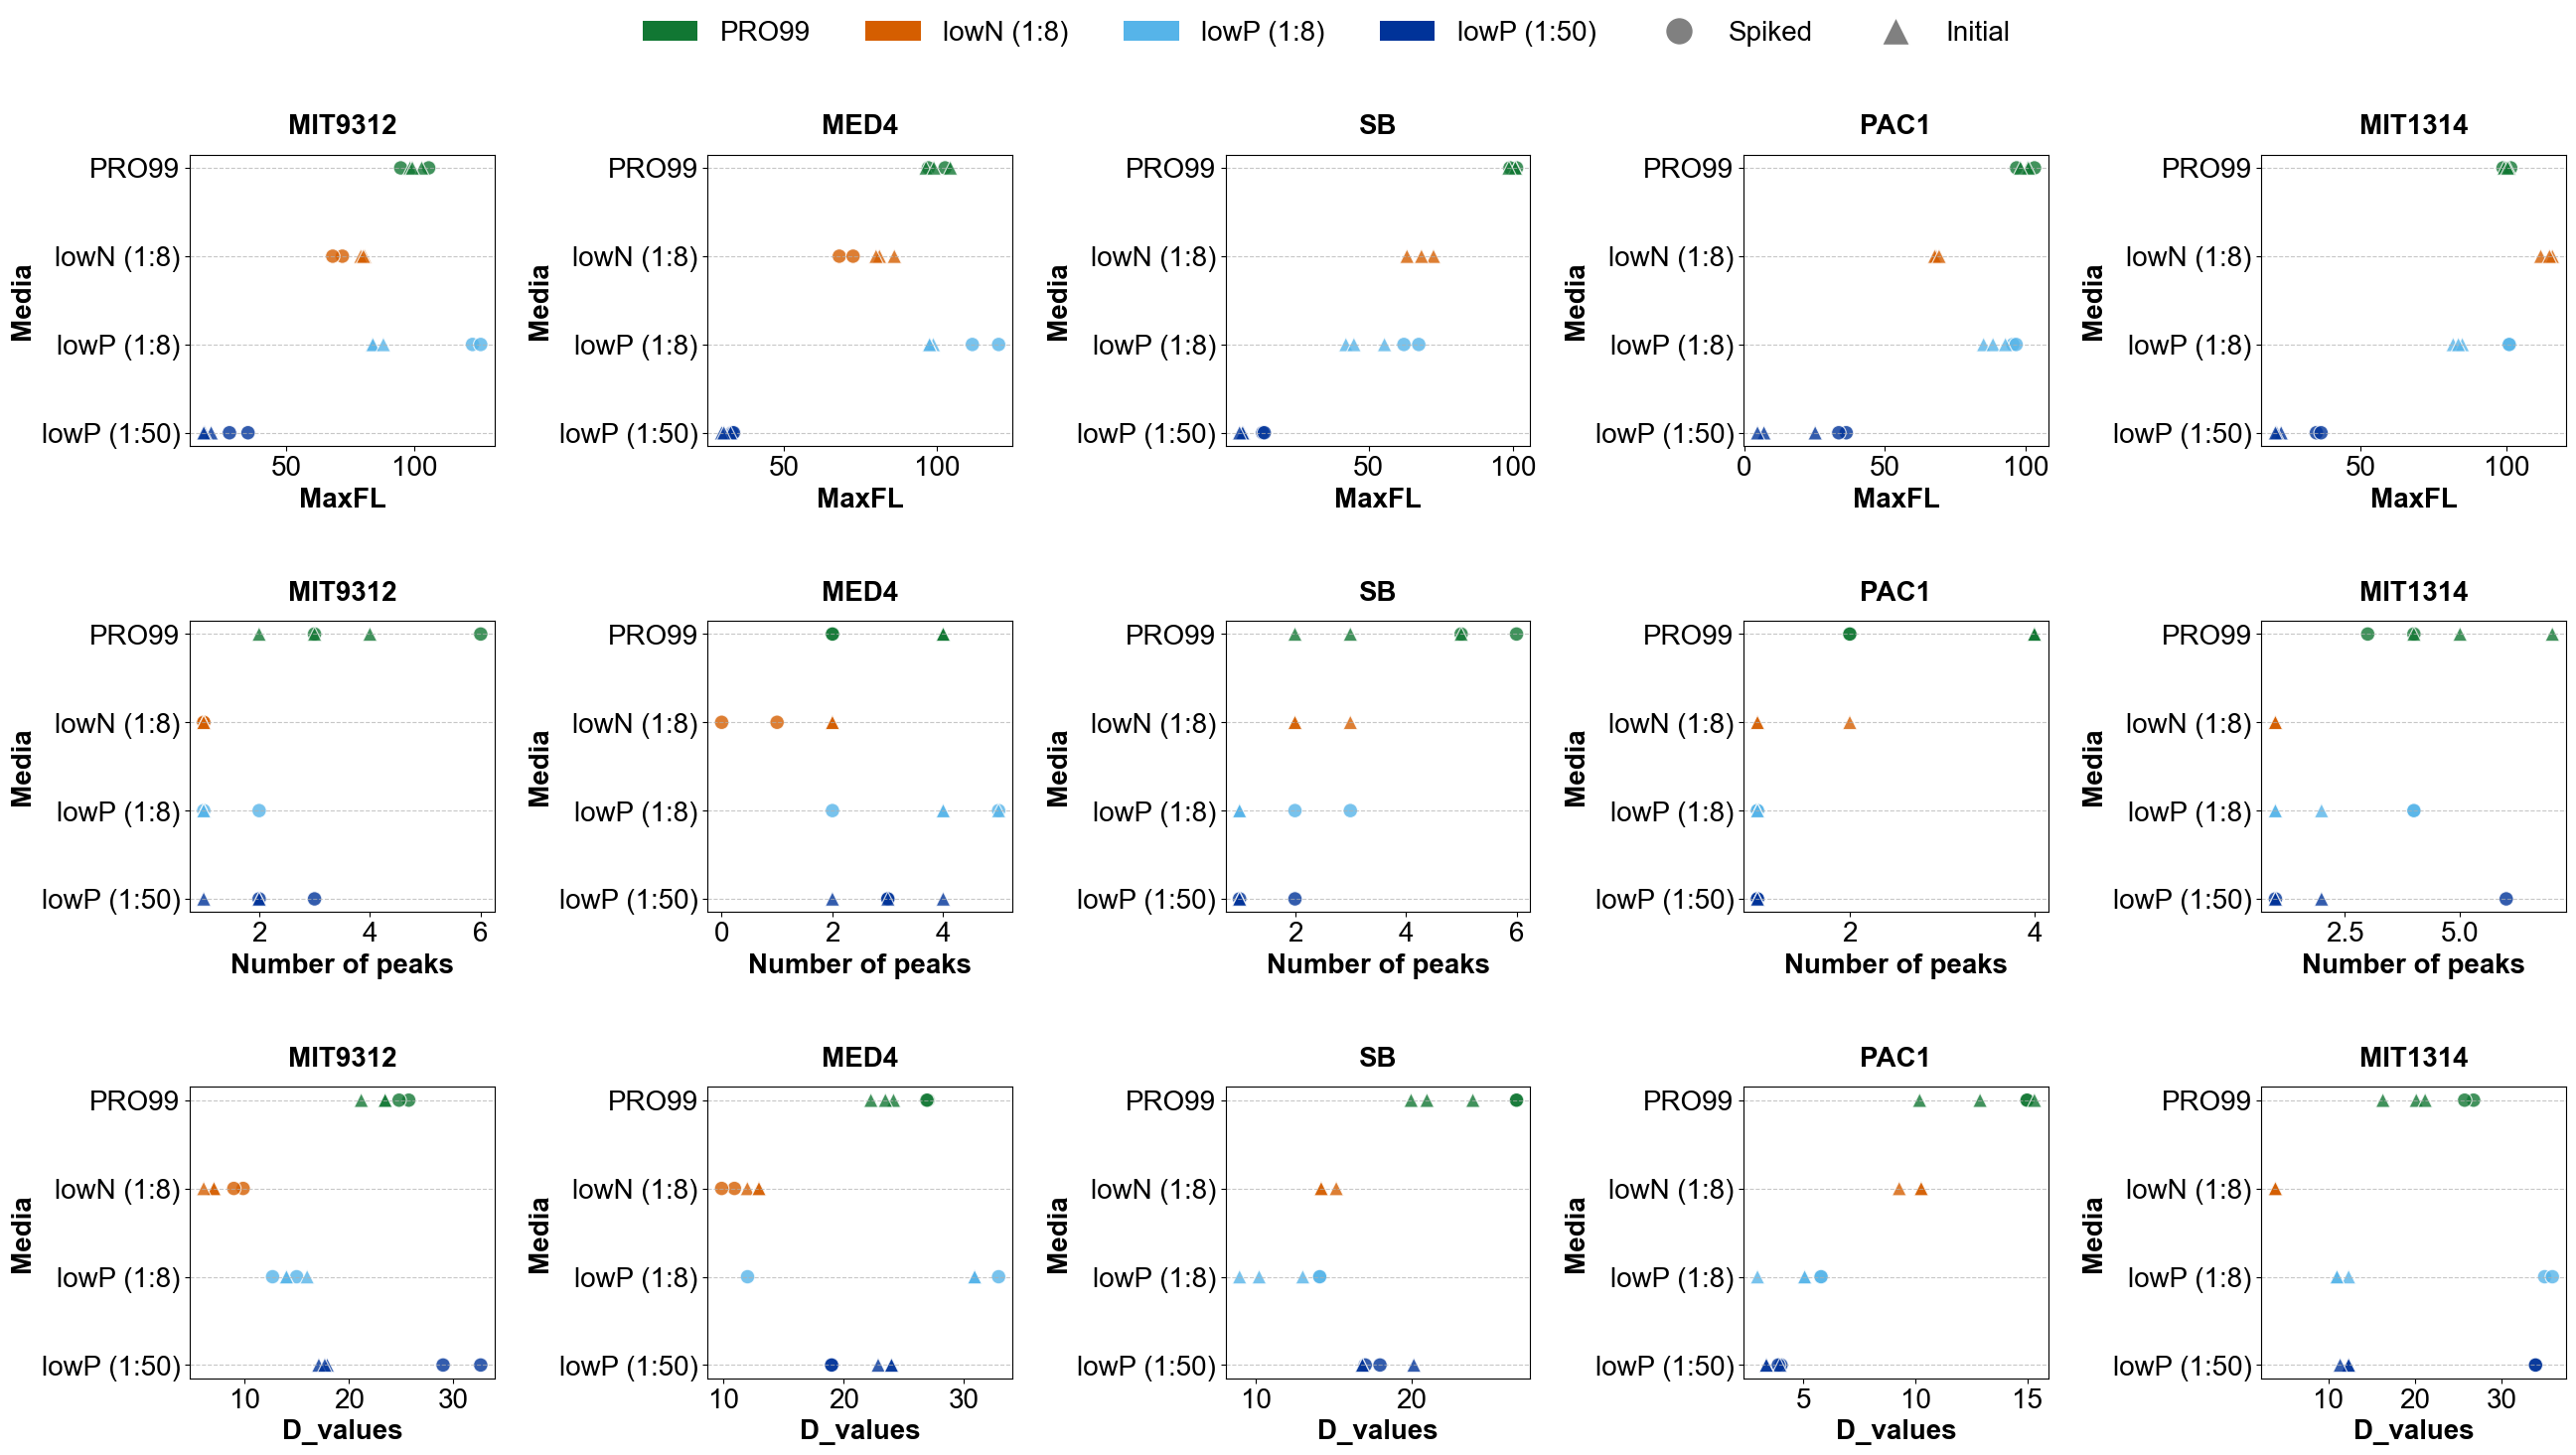

In [57]:
tubes_1_to_12 = [f"{letter}{i}" for letter in ['A', 'C', 'D'] for i in range(1, 13)]
tubes_13_to_24 = [f"{letter}{i}" for letter in ['A', 'C', 'D'] for i in range(13, 25)]
excluded_tubes = tubes_1_to_12 + tubes_13_to_24

intial_exp = intial_exp[~intial_exp['number_of_tube'].isin(excluded_tubes)]


media_palette = {
    "PRO99": "#117733",
    "lowN (1:8)": "#D55E00",
    "lowP (1:8)": "#56B4E9",
    "lowP (1:50)": "#003399",
}

strains = ['MIT9312', 'MED4', 'SB', 'PAC1', 'MIT1314']
metrics = ['norm_toPRO99', 'peak_count', 'D_value']


metric_labels = {
    'norm_toPRO99': 'MaxFL',
    'peak_count': 'Number of peaks',
    'D_value': 'D_values'
}


fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(26, 16))


for i, metric in enumerate(metrics):
    for j, strain in enumerate(strains):
        ax = axes[i, j]
        

        df_spiked = filtered_spiked[filtered_spiked['strain'] == strain]
        df_initial = intial_exp[intial_exp['strain'] == strain]
        

        if not df_spiked.empty:
            sns.scatterplot(
                data=df_spiked,
                x=metric,
                y='media',
                hue='media',
                palette=media_palette,
                style=df_spiked.apply(lambda _: 'Spiked', axis=1),
                markers={'Spiked': 'o'},
                ax=ax,
                legend=False,
                alpha=0.8,
                s=110
            )
            

        if not df_initial.empty:
            sns.scatterplot(
                data=df_initial,
                x=metric,
                y='media',
                hue='media',
                palette=media_palette,
                style=df_initial.apply(lambda _: 'Initial', axis=1),
                markers={'Initial': '^'},
                ax=ax,
                legend=False,
                alpha=0.8,
                s=110
            )
            

        ax.set_title(f"{strain}", fontsize=20, fontweight='bold', pad=15)
            

        ax.set_ylabel("Media", fontsize=20, fontweight='bold')
        ax.set_xlabel(metric_labels[metric], fontsize=20, fontweight='bold')
        

        ax.tick_params(axis='both', which='major', labelsize=20)

        ax.grid(axis='y', linestyle='--', alpha=0.7)


media_handles = [
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#117733', label='PRO99'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#D55E00', label='lowN (1:8)'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#56B4E9', label='lowP (1:8)'),
    mpatches.Rectangle((0, 0), 1, 1, facecolor='#003399', label='lowP (1:50)')
]

shape_handles = [
    Line2D([0], [0], marker='o', color='w', label='Spiked', markerfacecolor='gray', markersize=20),
    Line2D([0], [0], marker='^', color='w', label='Initial', markerfacecolor='gray', markersize=20)
]


fig.legend(handles=media_handles + shape_handles, 
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.95), 
           fontsize=20, 
           frameon=False, 
           ncol=6)


plt.subplots_adjust(top=0.85, bottom=0.08, left=0.06, right=0.98, hspace=0.6, wspace=0.7)

plt.show()